# Uncertainty vs Attention: Analyzing Model Failure in Computer Vision Models

This notebook compares whether prediction uncertainty or attention-based explanations provide a more reliable signal of model error in an image-based deep learning pipeline.

**Key results**
- Entropy is correlated to prediction error (Spearman coeff = 0.49)
- Uncertainty signals can detect high-error samples (ROC-AUC = 0.68)
- Attention-based signals perform near random (ROC-AUC = 0.51)

**Takeaway**

Prediction uncertainty is a substantially more reliable indicator of model failure than attention-based explanations in this setup. In practice, this enables production systems to flag or filter uncertain predictions, improving reliability and reducing the risk of incorrect automated decisions.

### Data Initialization

The dataset consists of noisy galaxy images paired with probabilistic labels describing morphological features. Each sample includes an image and a corresponding vector of class probabilities, making this a multi-label regression problem.

Images and labels are aligned via a galaxy identifier, ensuring consistent mapping between inputs and targets throughout the pipeline.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from pytorch_grad_cam import GradCAM
from torchvision import transforms
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import random
import torch
import os

from src.data_processing import *
from src.class_models import *
from src.train_models import *
from src.grad_cam import *
from src.plots import *

To obtain reproducible results, we set a seed for our code to run on. Also, we run the pipeline on a GPU.

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

We introduce our training set. We do this by making sure the GalaxyID column is the right type and we add filename column by adding jpg to the GalaxyID.

In [3]:
df = pd.read_csv("training_solutions_rev1.csv")

#add file names
df["GalaxyID"] = df["GalaxyID"].astype(str)
df["filename"] = df["GalaxyID"] + ".jpg"

print(df.shape)
df.head()

(61578, 39)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6,filename
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512,100008.jpg
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000,100023.jpg
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,100053.jpg
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000,100078.jpg
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,100090.jpg


### Data Split

The dataset is split into training and validation sets. The validation set is used for model selection and evaluation, providing an unbiased estimate of generalized performance.

Given the multi-label regression setting, consistent data splits are important to ensure comparable evaluation across models and uncertainty evaluations.

In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, shuffle=True)#random_state = seed, 

#use a smaller subset to make pipeline run faster
#train_df = train_df.sample(n=10000).reset_index(drop=True)#, random_state=seed
#val_df = val_df.sample(n=2500).reset_index(drop=True)#, random_state=seed)

print(f"Training subset length: {len(train_df)}")
print(f"Validation subset: {len(val_df)}")

Training subset length: 49262
Validation subset: 12316


The target variables correspond to the set of `Class...` columns, which represent probabilistic annotations of galaxy features. 

In [5]:
target_cols = []

for col in df.columns:
  if col not in ["GalaxyID", "filename"]:
    target_cols.append(col)

n_targets = len(target_cols)

### Data Visualization

Random samples from the dataset show significant differences in galaxy morphology, scale, and image quality. Differences in brightness, structure, and resolution introduce features which our model will learn to distinguish.

These differences in appearance motivates the use of convolutional architectures.

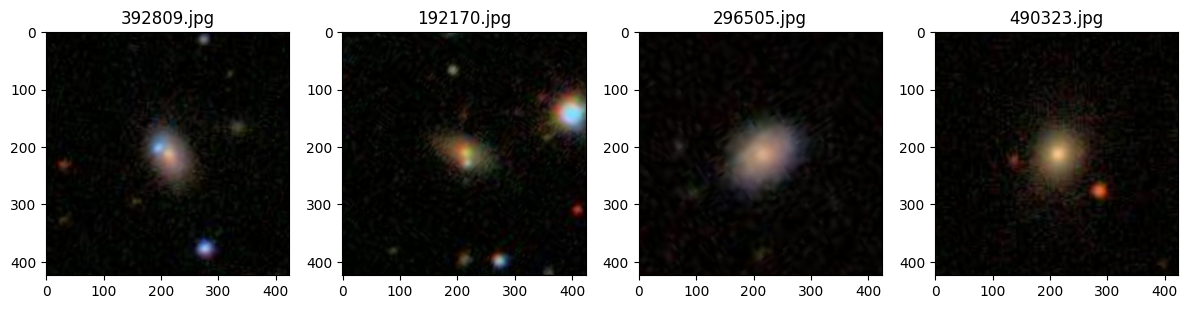

In [6]:
img_dir = "images_training_rev1"

fig, axes = plt.subplots(1, 4, figsize=(12, 6))

n_samples = 4
sample_files = random.sample(list(train_df["filename"]), n_samples)

for i in range(n_samples):
    fig_name = sample_files[i]
    
    path = os.path.join(img_dir, fig_name)
    img = Image.open(path).convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(fig_name)

plt.tight_layout()
plt.show()

### Data Transformation

Data augmentation is applied to increase sample diversity and improve generalization. Random flips, rotations, and jittering simulate different variations in orientation and imaging present in astronomical observations.

Images are resized to 224×224 to match the input requirements of the CNN architectures (ResNet-28, EfficientNet-b0), ensuring consistent training and evaluation across models.

In [7]:
batch_size = 8
epochs = 10
learning_rate = 1e-4
n_workers = 2
img_size = 224
eps = 1e-8 #constant to avoid log divergences

In [8]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

In [9]:
resnet_train_transform = transforms.Compose([transforms.Resize((img_size, img_size)), 
                                             transforms.RandomHorizontalFlip(),
                                             transforms.RandomVerticalFlip(),
                                             transforms.RandomRotation(30),
                                             transforms.ColorJitter(0.1, 0.1, 0.1),
                                             transforms.ToTensor(),
                                             transforms.Normalize(imagenet_mean, imagenet_std)])

resnet_val_transform = transforms.Compose([transforms.Resize((img_size, img_size)),
                                           transforms.ToTensor(),
                                           transforms.Normalize(imagenet_mean, imagenet_std)])

In [10]:
effnet_train_transform = transforms.Compose([transforms.Resize((img_size, img_size)),
                                             transforms.RandomHorizontalFlip(),
                                             transforms.RandomVerticalFlip(),
                                             transforms.RandomRotation(30),
                                             transforms.ColorJitter(0.1, 0.1, 0.1),
                                             transforms.ToTensor(),
                                             transforms.Normalize(imagenet_mean, imagenet_std)])

effnet_val_transform = transforms.Compose([transforms.Resize((img_size, img_size)),
                                           transforms.ToTensor(),
                                           transforms.Normalize(imagenet_mean, imagenet_std)])

### Data Loading (Batching)

Training data is loaded in mini-batches to enable GPU-based training. Each batch consists of images and corresponding target vectors, with preprocessing and augmentation applied each batch.

Shuffling is used during training to prevent ordering effects and improve generalization.

In [11]:
resnet_train_batches = create_batches(train_df, img_dir, resnet_train_transform, batch_size, target_cols, True)
resnet_val_batches = create_batches(val_df, img_dir, resnet_val_transform, batch_size, target_cols, True)

effnet_train_batches = create_batches(train_df, img_dir, effnet_train_transform, batch_size, target_cols, True)
effnet_val_batches = create_batches(val_df, img_dir, effnet_val_transform, batch_size, target_cols, True)

### Modeling

A simple baseline is defined by predicting the mean of each target variable from the training data. Convolutional neural networks (ResNet-18 and EfficientNet-b0) are then trained to learn image-based representations and improve upon this baseline. These architectures allow comparison between standard and more efficient transformer-based vision models, given our setup.

The task is optimized using mean squared error (MSE), consistent with the multi-label regression setting. Training uses AdamW with cosine annealing to support stable convergence.

In [12]:
mean_values = train_df[target_cols].mean().values
mean_target = torch.tensor(mean_values, dtype=torch.float32)

baseline_score = baseline_rmse(val_df, mean_target, target_cols)
print(f"Baseline RMSE: {baseline_score}")

Baseline RMSE: 0.16383127868175507


Now we tain our ResNet-18 and EfficientNet-b0 models. The models are trained on their respective datasets for 10 epochs each.

In [13]:
resnet_model = resnet18(n_targets)

resnet_history, resnet_best_rmse, resnet_path = train_model(resnet_model, "resnet18", target_cols, train_df, val_df, img_dir,
                                                            resnet_train_transform, resnet_val_transform, epochs, learning_rate, 
                                                            batch_size)

resnet18: Epoch 1/10 -- train_loss=0.0155 -- val_loss=0.0102 -- val_rmse=0.1009
resnet18: Epoch 2/10 -- train_loss=0.0101 -- val_loss=0.0096 -- val_rmse=0.0982
resnet18: Epoch 3/10 -- train_loss=0.0091 -- val_loss=0.0086 -- val_rmse=0.0925
resnet18: Epoch 4/10 -- train_loss=0.0084 -- val_loss=0.0081 -- val_rmse=0.0900
resnet18: Epoch 5/10 -- train_loss=0.0081 -- val_loss=0.0079 -- val_rmse=0.0886
resnet18: Epoch 6/10 -- train_loss=0.0078 -- val_loss=0.0076 -- val_rmse=0.0871
resnet18: Epoch 7/10 -- train_loss=0.0076 -- val_loss=0.0075 -- val_rmse=0.0865
resnet18: Epoch 8/10 -- train_loss=0.0074 -- val_loss=0.0074 -- val_rmse=0.0859
resnet18: Epoch 9/10 -- train_loss=0.0073 -- val_loss=0.0074 -- val_rmse=0.0860
resnet18: Epoch 10/10 -- train_loss=0.0072 -- val_loss=0.0073 -- val_rmse=0.0853


In [14]:
effnet_model = efficientnet_b0(n_targets)

effnet_history, effnet_best_rmse, effnet_path = train_model(effnet_model, "efficientnet_b0", target_cols, train_df, val_df, img_dir,
                                                            effnet_train_transform, effnet_val_transform, epochs, learning_rate, 
                                                            batch_size)

efficientnet_b0: Epoch 1/10 -- train_loss=0.0147 -- val_loss=0.0100 -- val_rmse=0.1001
efficientnet_b0: Epoch 2/10 -- train_loss=0.0094 -- val_loss=0.0084 -- val_rmse=0.0918
efficientnet_b0: Epoch 3/10 -- train_loss=0.0083 -- val_loss=0.0083 -- val_rmse=0.0910
efficientnet_b0: Epoch 4/10 -- train_loss=0.0077 -- val_loss=0.0076 -- val_rmse=0.0870
efficientnet_b0: Epoch 5/10 -- train_loss=0.0073 -- val_loss=0.0075 -- val_rmse=0.0868
efficientnet_b0: Epoch 6/10 -- train_loss=0.0070 -- val_loss=0.0076 -- val_rmse=0.0872
efficientnet_b0: Epoch 7/10 -- train_loss=0.0067 -- val_loss=0.0072 -- val_rmse=0.0850
efficientnet_b0: Epoch 8/10 -- train_loss=0.0065 -- val_loss=0.0070 -- val_rmse=0.0837
efficientnet_b0: Epoch 9/10 -- train_loss=0.0063 -- val_loss=0.0067 -- val_rmse=0.0821
efficientnet_b0: Epoch 10/10 -- train_loss=0.0062 -- val_loss=0.0068 -- val_rmse=0.0823


### Model Evaluation

Model performance is evaluated against the baseline using validation MSE, providing a direct measure of improvement over naive predictions. RMSE is tracked across training epochs to monitor convergence and compare learning dynamics between models.

RMSE is also used as the primary error metric in the test set analysis. Use of this metric is further elaborated in the test set section.

We observe a similar performance across our ResNet-18 and EfficientNet-b0 models. Both significantly outperform our baseline model. For further purposes, we will pick EfficientNet-b0 as our main model, since it achieved the lowest validation RMSE.

In [15]:
results_df = pd.DataFrame({"model": ["baseline_mean", "resnet18", "efficientnet_b0"],
                           "val_rmse": [baseline_score, resnet_best_rmse, effnet_best_rmse]})

results_df = results_df.sort_values("val_rmse").reset_index(drop=True)
results_df

,model,val_rmse
0,efficientnet_b0,0.082136
1,resnet18,0.085301
2,baseline_mean,0.163831


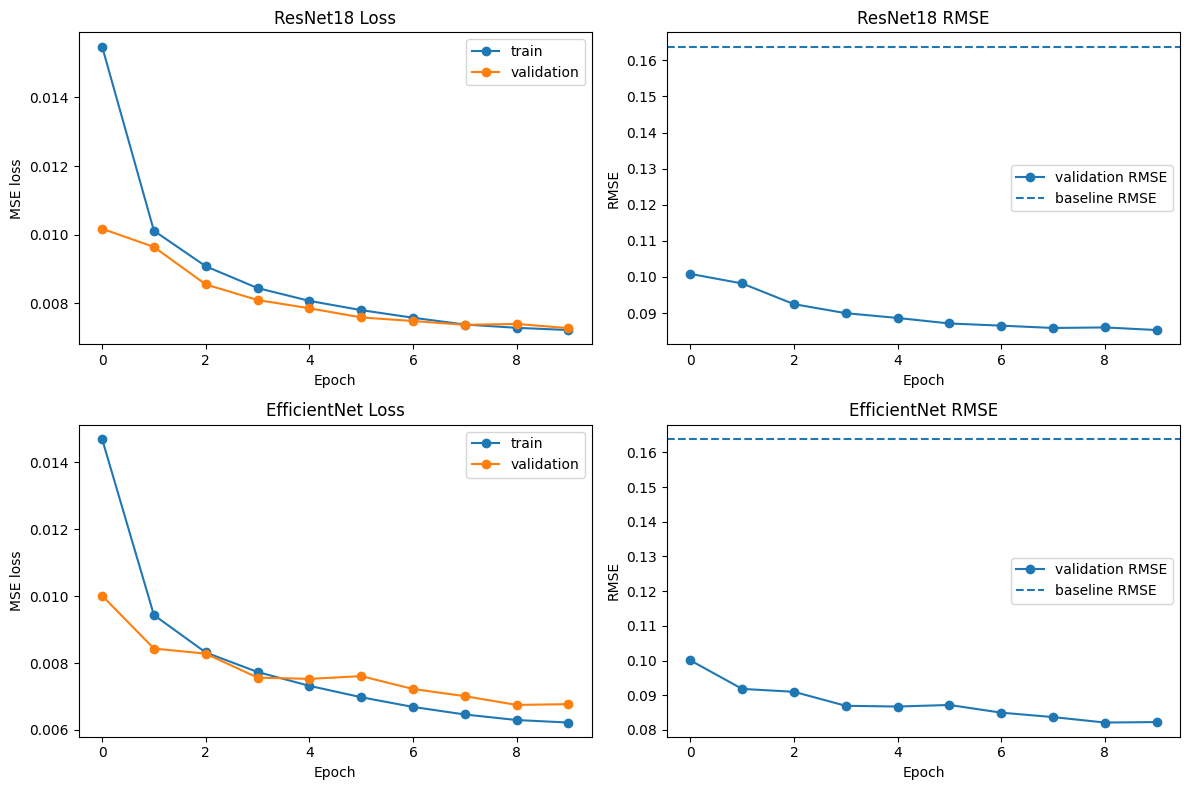

In [18]:
learning_curve(resnet_history, effnet_history, baseline_score)

In [19]:
state_dict = torch.load(effnet_path, map_location=device)
effnet_model.load_state_dict(state_dict)
effnet_model.eval();

In [20]:
images, targets = next(iter(effnet_val_batches))

with torch.no_grad():
    preds = torch.sigmoid(effnet_model(images.to(device))).cpu()

### Grad-CAM & Uncertainty Analysis

To visualize which parts of an image the model focuses on, we use **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

Grad-CAM requires selecting a **target layer** from the model. This is typically one of the last convolutional layers, since it retains spatial information while capturing high-level features.

For the EfficientNet-b0 model, we choose

```python 
target_layers = [effnet_model.conv_head]
```

In [21]:
target_layers = [effnet_model.conv_head]
cam = GradCAM(model = effnet_model, target_layers = target_layers)

After collecting model predictions on the validation set, we compute two per-sample metrics.

We also determine the sample RMSE and define the entropy by
$$H(p) = -\frac{1}{N} \sum_{i=1}^{N} \left( p_i \log(p_i) + (1 - p_i) \log(1 - p_i) \right),$$
where $p_i$ denotes the probability of an image having the label $i$.

In [22]:
all_probs, all_targets = get_predictions(effnet_model, val_df, img_dir, effnet_val_transform, target_cols, batch_size)

sample_rmse = torch.sqrt(((all_probs - all_targets) ** 2).mean(dim=1))
entropy = -(all_probs * torch.log(all_probs + eps) +
            (1 - all_probs) * torch.log(1 - all_probs + eps)).mean(dim=1)

rmse_np = sample_rmse.detach().cpu().numpy()
entropy_np = entropy.detach().cpu().numpy()

### Grad-CAM 

Grad-CAM heatmaps are inspected for both high-error and low-error predictions to assess whether model attention aligns with prediction quality.

While attention maps generally highlight plausible galaxy structures, they do not reliably distinguish between accurate and erroneous predictions. High-error cases often exhibit similar attention patterns to low-error cases.

This suggests that attention alone is not a strong indicator of model reliability, motivating the use of uncertainty-based signals for error detection.

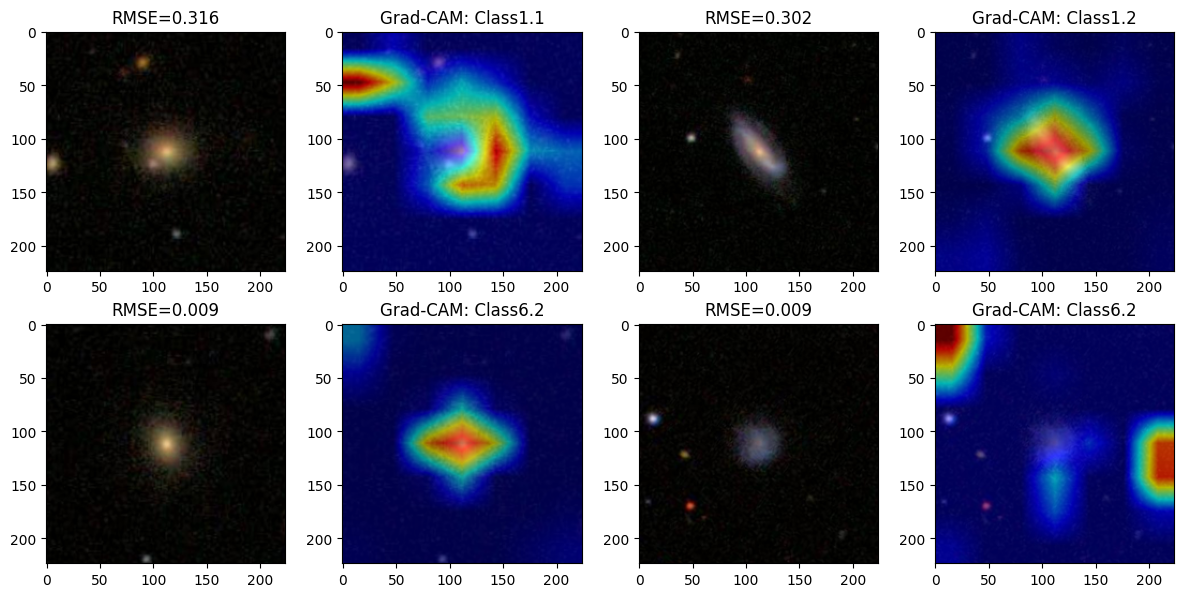

In [23]:
plot_gradcam(effnet_model, cam, val_df, img_dir, effnet_val_transform, rmse_np, target_cols)

### Uncertainty vs Error

Prediction uncertainty (measured via entropy) is compared against model error (RMSE) to assess whether uncertainty provides a useful signal of prediction quality.

A moderate positive relationship is observed (Spearman = 0.50), indicating that higher uncertainty is generally associated with larger prediction errors. While the variance is substantial, the overall trend suggests that uncertainty captures meaningful information about model reliability.

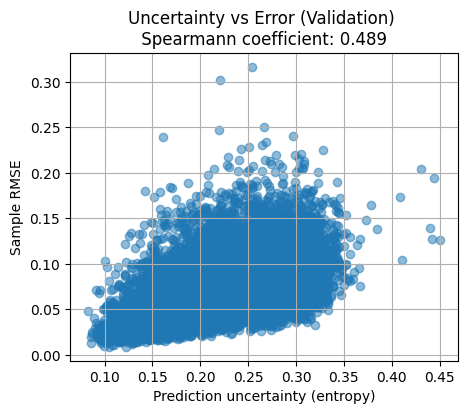

In [24]:
#spearman coefficient
spearman_corr, spearman_p = spearmanr(entropy_np, rmse_np)

#plot uncertainty vs error
plt.figure(figsize=(5, 4))
plt.scatter(entropy_np, rmse_np, alpha=0.5)
plt.xlabel("Prediction uncertainty (entropy)")
plt.ylabel("Sample RMSE")
plt.title(f"Uncertainty vs Error (Validation) \n Spearmann coefficient: {spearman_corr:.3f} ")
plt.grid(True)
plt.show()

### Error Detection via Uncertainty

The ability to identify high-error predictions is evaluated using ROC-AUC, comparing prediction entropy and Grad-CAM–based signals.

Prediction entropy achieves good performance (ROC-AUC = 0.70), indicating that it can effectively distinguish between low- and high-error samples. In contrast, Grad-CAM–based signals perform near random (ROC-AUC = 0.52), providing little value for error detection.

These results confirm that uncertainty is a substantially more reliable indicator of model failure than attention-based measures.

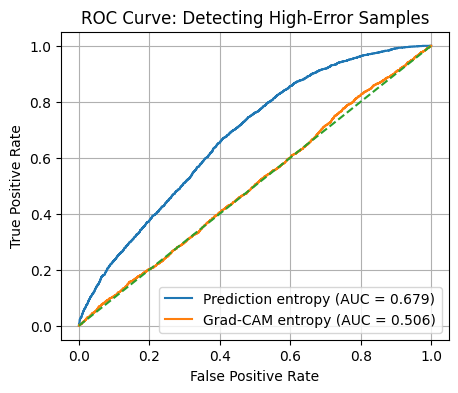

In [25]:
rmse_threshold = np.percentile(rmse_np, 80)
high_error = (rmse_np >= rmse_threshold).astype(int)

auc_entropy = roc_auc_score(high_error, entropy_np)
fpr, tpr, _ = roc_curve(high_error, entropy_np)

cam_entropy_vals = CAM_entropy(effnet_model, cam, val_df, img_dir, effnet_val_transform)

auc_cam = roc_auc_score(high_error, cam_entropy_vals)
fpr_cam, tpr_cam, _ = roc_curve(high_error, cam_entropy_vals)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Prediction entropy (AUC = {auc_entropy:.3f})")
plt.plot(fpr_cam, tpr_cam, label=f"Grad-CAM entropy (AUC = {auc_cam:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve: Detecting High-Error Samples")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

### Filtering Uncertain Predictions

In the following section we filter uncertain predictions and monitor performance. We can observe that removing high-entropy samples consistently reduces RMSE, while random removal shows little to no improvement.

This indicates that prediction uncertainty is a meaningful signal of model reliability: higher entropy corresponds to higher error, and filtering these samples improves overall performance.

Overall, uncertainty can be effectively used to rank predictions and identify high-risk cases.

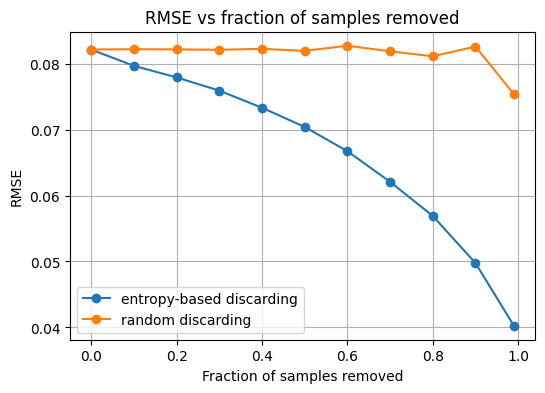

In [26]:
fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7 ,0.8, 0.9, 0.99]

y_pred = all_probs.cpu().numpy()
y_true = all_targets.cpu().numpy()

#entropy-based removal
order = np.argsort(entropy_np)
n = len(entropy_np)

#rmse list for entropy-based removal
rmse_vals = []
for frac in fractions:
    cutoff = int(n * (1 - frac))
    cutoff_i = order[:cutoff]

    rmse = np.sqrt(np.mean((y_pred[cutoff_i] - y_true[cutoff_i]) ** 2))
    rmse_vals.append(rmse)

#random baseline rmse list generation
random_rmse = []
for frac in fractions:
    cutoff = int(n * (1 - frac))
    cutoff_i = np.random.choice(n, cutoff, replace=False)

    rmse = np.sqrt(np.mean((y_pred[cutoff_i] - y_true[cutoff_i]) ** 2))
    random_rmse.append(rmse)

#plot
plt.figure(figsize=(6, 4))
plt.plot(fractions, rmse_vals, marker="o", label="entropy-based discarding")
plt.plot(fractions, random_rmse, marker="o", label="random discarding")
plt.title("RMSE vs fraction of samples removed")
plt.xlabel("Fraction of samples removed")
plt.ylabel("RMSE")
plt.grid(True)
plt.legend()
plt.show()

## Results & Conclusion

Prediction uncertainty provides a more informative signal of model reliability than Grad-CAM attention patterns. While attention maps appear visually plausible across both high- and low-error samples, they do not reliably distinguish between accurate and erroneous predictions (ROC-AUC = 0.51).

In contrast, entropy-based uncertainty shows a moderate positive relationship with prediction error (Spearman = 0.51) and enables effective detection of high-error samples (ROC-AUC = 0.70). Although not perfectly separable, uncertainty provides a meaningful signal for ranking prediction reliability.

Importantly, this is not guaranteed: a model can be confidently wrong, meaning uncertainty and error are not inherently aligned. The observed relationship therefore reflects that the model’s uncertainty is at least partially calibrated.

Additionally, filtering high-entropy samples leads to a consistent reduction in RMSE, outperforming random removal and demonstrating that uncertainty can be used to improve overall prediction quality.

Grad-CAM should therefore be interpreted as a qualitative tool for inspecting model behavior, whereas uncertainty serves as a quantitative signal for identifying unreliable predictions.

### Key Takeaways
- Attention maps are visually meaningful but not discriminative for error detection  
- Prediction uncertainty is a stronger and more actionable indicator of model reliability  
- Uncertainty can be used to flag or filter high-risk predictions  

Overall, uncertainty-based methods are better suited for reliability assessment, while attention-based methods remain useful for interpretability rather than decision-making. In practice, this enables more robust deployment pipelines by allowing systems to flag uncertain predictions for review or exclusion, improving reliability in real-world applications.

### Addition: Test Set application

The final model is applied to the held-out test set to generate predictions for unseen data. Each input image is mapped to a vector of probabilistic outputs describing galaxy morphology.

These predictions represent the final output of the pipeline and can be used for downstream analysis or evaluation in real-world settings.

In [27]:
test_img_dir = "images_test_rev1"

test_files = os.listdir(test_img_dir)

galaxy_ids = []
for file in test_files:
    galaxy_id = file.split(".")[0]
    galaxy_ids.append(galaxy_id)
    
test_df = pd.DataFrame({
    "GalaxyID": galaxy_ids,
    "filename": test_files
})

test_df.head()

,GalaxyID,filename
0,534028,534028.jpg
1,161590,161590.jpg
2,503684,503684.jpg
3,835967,835967.jpg
4,702536,702536.jpg


In [28]:
best_model_name = "efficientnet_b0"

test_transform = effnet_val_transform

best_model = efficientnet_b0(n_targets)
best_model.load_state_dict(torch.load(effnet_path, map_location=device))
best_model.to(device)
best_model.eval();

In [29]:
all_preds = []
all_ids = []

test_batches = create_batches(test_df, test_img_dir, test_transform, batch_size, target_cols, False)

with torch.no_grad():
    for images, galaxy_ids in test_batches:
        images = images.to(device)

        outputs = best_model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(probs)
        all_ids.extend(galaxy_ids)

In [30]:
all_preds = np.vstack(all_preds)

result = pd.DataFrame(all_preds, columns=target_cols)
result.insert(0, "GalaxyID", all_ids)

result.to_csv("result.csv", index=False)

print(result.shape)
result.head()

(79975, 38)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,804186,0.244584,0.741496,0.007019,0.320017,0.436849,0.196788,0.233627,0.270128,0.154949,...,0.051071,0.086824,0.117693,0.055124,0.004761,0.235487,0.005287,0.003460,0.002005,0.076627
1,269903,0.049535,0.953818,0.003797,0.185258,0.758097,0.349222,0.321527,0.696762,0.069078,...,0.049104,0.122015,0.235509,0.182289,0.003841,0.665860,0.013238,0.005065,0.001124,0.050717
2,605182,0.596875,0.365982,0.026648,0.022453,0.341922,0.009429,0.328896,0.040475,0.331294,...,0.002265,0.019332,0.013944,0.007642,0.002865,0.007357,0.001412,0.001117,0.002802,0.033712
3,126908,0.193401,0.766645,0.023640,0.021493,0.755809,0.541103,0.195114,0.336888,0.429523,...,0.015708,0.129887,0.154681,0.048994,0.033696,0.193133,0.010929,0.004574,0.004515,0.091872
4,886330,0.108456,0.853728,0.019343,0.275902,0.566525,0.122410,0.406005,0.306849,0.171223,...,0.088424,0.057410,0.065400,0.169727,0.054698,0.142261,0.011981,0.008968,0.005052,0.106022
